In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io
import os
from collections import Counter
from IPython.display import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re
from nltk.tokenize import word_tokenize

nltk.download('punkt')

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Ayush\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [63]:
df=pd.read_csv('../datasets/spam_ham_dataset.csv',encoding='latin1')
df

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0
...,...,...,...,...
5166,1518,ham,Subject: put the 10 on the ft\r\nthe transport...,0
5167,404,ham,Subject: 3 / 4 / 2000 and following noms\r\nhp...,0
5168,2933,ham,Subject: calpine daily gas nomination\r\n>\r\n...,0
5169,1409,ham,Subject: industrial worksheets for august 2000...,0


In [64]:
df['label'].value_counts()

label
ham     3672
spam    1499
Name: count, dtype: int64

In [65]:
nltk.download('stopwords')
nltk.download('wordnet')
stop_words=set(stopwords.words('english'))  ## make a stopword
lemmatizer = WordNetLemmatizer()  


def clean_text(text):
    text=text.lower()

  
    # Remove punctuation & numbers

    text=re.sub(r'[^a-z\s]','',text)
    ## Tokenize using split 

    words=word_tokenize(text)

    # remove stopword +lemetization
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    return " ".join(words)

df['text'] = df['text'].apply(clean_text)     


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Ayush\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Ayush\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [66]:
df

,Unnamed: 0,label,text,label_num
0,605,ham,subject enron methanol meter follow note gave ...,0
1,2349,ham,subject hpl nom january see attached file hpln...,0
2,3624,ham,subject neon retreat ho ho ho around wonderful...,0
3,4685,spam,subject photoshop window office cheap main tre...,1
4,2030,ham,subject indian spring deal book teco pvr reven...,0
...,...,...,...,...
5166,1518,ham,subject put ft transport volume decreased cont...,0
5167,404,ham,subject following noms hpl take extra mmcf wee...,0
5168,2933,ham,subject calpine daily gas nomination julie men...,0
5169,1409,ham,subject industrial worksheet august activity a...,0


In [67]:
count1=Counter(' '.join(df[df['label']=='ham']['text']).split()).most_common(20)
df1=pd.DataFrame.from_dict(count1)
df1=df1.rename(columns={0:'words in non-spam',1:'count_'})
count2=Counter(' '.join(df[df['label']=='spam']['text']).split()).most_common(20)
df2=pd.DataFrame.from_dict(count2)
df2=df2.rename(columns={0:'words in spam',1:'count_'})

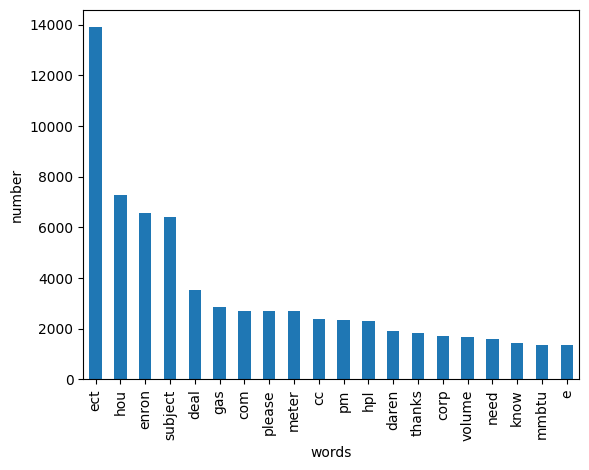

In [68]:
df1.plot.bar(legend=False)
y_pos=np.arange(len(df1['words in non-spam']))
plt.xticks(y_pos,df1['words in non-spam'])
plt.title('')
plt.xlabel('words')
plt.ylabel('number')
plt.show()

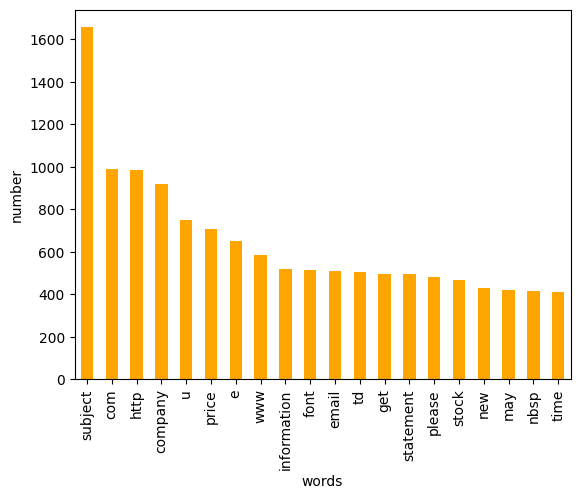

In [69]:
df2.plot.bar(legend=False,color='orange')
y_pos=np.arange(len(df2["words in spam"]))
plt.xticks(y_pos,df2['words in spam'])
plt.title('')
plt.xlabel('words')
plt.ylabel('number')
plt.show()

### Now we are doing feature embedding 

In [85]:
from sklearn import feature_extraction


x=feature_extraction.text.CountVectorizer()
x=x.fit_transform(df['text']).toarray()
x.shape



(5171, 43226)

In [86]:
x

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(5171, 43226))

In [71]:
y=df['label_num']
y

0       0
1       0
2       0
3       1
4       0
       ..
5166    0
5167    0
5168    0
5169    0
5170    1
Name: label_num, Length: 5171, dtype: int64

### Grid Search
- why do we use grid search ?

`GridSearchCV` is a technique to search through the best parameter values from the given set of the grid of parameters.it is basically a cross-validation method the model and the parameters are required to be fed in .best parameter values are extracted and then the prediction are made 



In [82]:
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score


models={
    "Multinomial Naive Bayes" : MultinomialNB(),
    "Gaussian Naive Bayes" : GaussianNB(),
    "SVC":SVC()
}

### Here is a generic function to check and evaluate the model performance 

In [87]:
## create a function
from sklearn.model_selection import train_test_split

def evaluate(x_value,y_value,models):


    x_train,x_test,y_train,y_test=train_test_split(x_value,y_value,test_size=0.3,random_state=42)

    models_list=[]
    scores=[]


    for i in range(len(list(models))):
        model=list(models.values())[i]
        model.fit(x_train,y_train)
        y_predict=model.predict(x_test)


        score=accuracy_score(y_test,y_predict)
        model_name=list(models.keys())[i]

        print(f'----score for ----{model_name}-----')
        print(f'{score}')
        models_list.append(model_name)
        scores.append(score)


    
    report=pd.DataFrame()

    report['model_name']=models_list
    report['model_score']=scores


    return report



evaluate(x,y,models)


----score for ----Multinomial Naive Bayes-----
0.976159793814433
----score for ----Gaussian Naive Bayes-----
0.9606958762886598
----score for ----SVC-----
0.967139175257732


,model_name,model_score
0,Multinomial Naive Bayes,0.976160
1,Gaussian Naive Bayes,0.960696
2,SVC,0.967139


### From the report i can say that Multinomial naive bayes perform significanly well then any other model 



### Performing Hyperparameter Tunning 

In [88]:
  x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [91]:

param = {
    'alpha': [0.001, 0.01, 0.1, 0.5, 1]
}

model=MultinomialNB()
# Using GridSearchCV
grid=GridSearchCV(model,param,cv=5)
grid.fit(x_train,y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",MultinomialNB()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter indexes 

In [95]:
grid.best_params_

{'alpha': 0.01}

In [96]:
grid.best_score_

np.float64(0.9790017040721978)

In [101]:
spam_detect_model=MultinomialNB(**grid.best_params_)
spam_detect_model.fit(x_train,y_train)

y_pred=spam_detect_model.predict(x_test)

confusion_m=confusion_matrix(y_test,y_pred)
accuracy=accuracy_score(y_test,y_pred)

print(f'The accuracy score of the model is{accuracy}')
print(f'The accuracy score of the model is \n {confusion_m}')




The accuracy score of the model is0.9780927835051546
The accuracy score of the model is 
 [[1101   20]
 [  14  417]]


In [105]:
classification=classification_report(y_test,y_pred)
print(classification)

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1121
           1       0.95      0.97      0.96       431

    accuracy                           0.98      1552
   macro avg       0.97      0.97      0.97      1552
weighted avg       0.98      0.98      0.98      1552



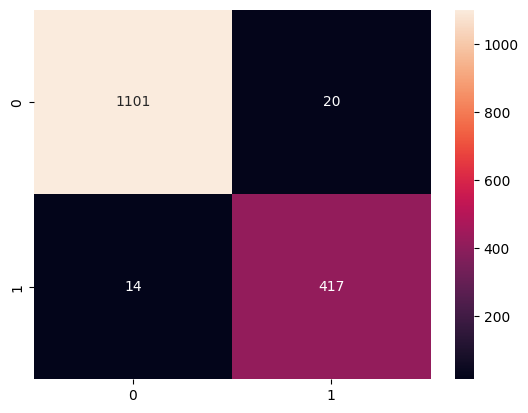

In [107]:
import seaborn as sns 
corr=sns.heatmap(confusion_m,annot=True,fmt='d')


### Repot 
- we see the model pefrom excellent 
- We can use MultinomialNB with alphs 0.01